### 1)

2) We performed a pore analysis of IRMOF-1, with a probe radius of 1.525 Angstrom. We obtained as follows:
density: 0.576983 g/cm^3
ASA_A^2: 3964.65 A^2
POAV: 13737.4 A^3
porosity or POAV_Volume_fraction: 0.77498

pk: 5

3. pk: 294 (CO2 only henry coeff)
pk: 329 (CH4, only hery coeff
)

4. pk: 373 (CO2), pk: 391 (CH4)

## 5) Binary mixture isotherms

In [4]:
import pyiast
df_ch4 = pd.read_csv("CH4_IRMOF1.csv")
df_co2 = pd.read_csv("CO2_IRMOF1.csv")

In [5]:
df_ch4.head()


,Pressure(bar),Loading(mmol/g),Unnamed: 2,Unnamed: 3
0,0.1,0.010812,NaN,NaN
1,0.5,0.059352,NaN,NaN
2,0.9,0.104386,NaN,NaN
3,1.3,0.148186,NaN,NaN
4,1.7,0.198804,NaN,NaN


In [6]:
df_co2.head()

,Pressure(bar),Loading(mmol/g),Unnamed: 2,Unnamed: 3
0,0.1,0.053378,NaN,NaN
1,0.5,0.273871,NaN,NaN
2,0.9,0.505175,NaN,NaN
3,1.3,0.751415,NaN,NaN
4,1.7,1.009247,NaN,NaN


CH4 data shape: (26, 2)
CO2 data shape: (26, 2)
Pressure range: 21 points from 0.1 to 4.1000000000000005 bar

Calculating binary mixture isotherms using IAST...
Error at pressure 3.500000000000001 bar: To compute the spreading pressure at this bulk
            gas pressure, we would need to extrapolate the isotherm since this
            pressure is outside the range of the highest pressure in your
            pure-component isotherm data, 10.100000.

            At present, your InterpolatorIsotherm object is set to throw an
            exception when this occurs, as we do not have data outside this
            pressure range to characterize the isotherm at higher pressures.

            Option 1: fit an analytical model to extrapolate the isotherm
            Option 2: pass a `fill_value` to the construction of the
                InterpolatorIsotherm object. Then, InterpolatorIsotherm will
                assume that the uptake beyond pressure 10.100000 is equal to
                `

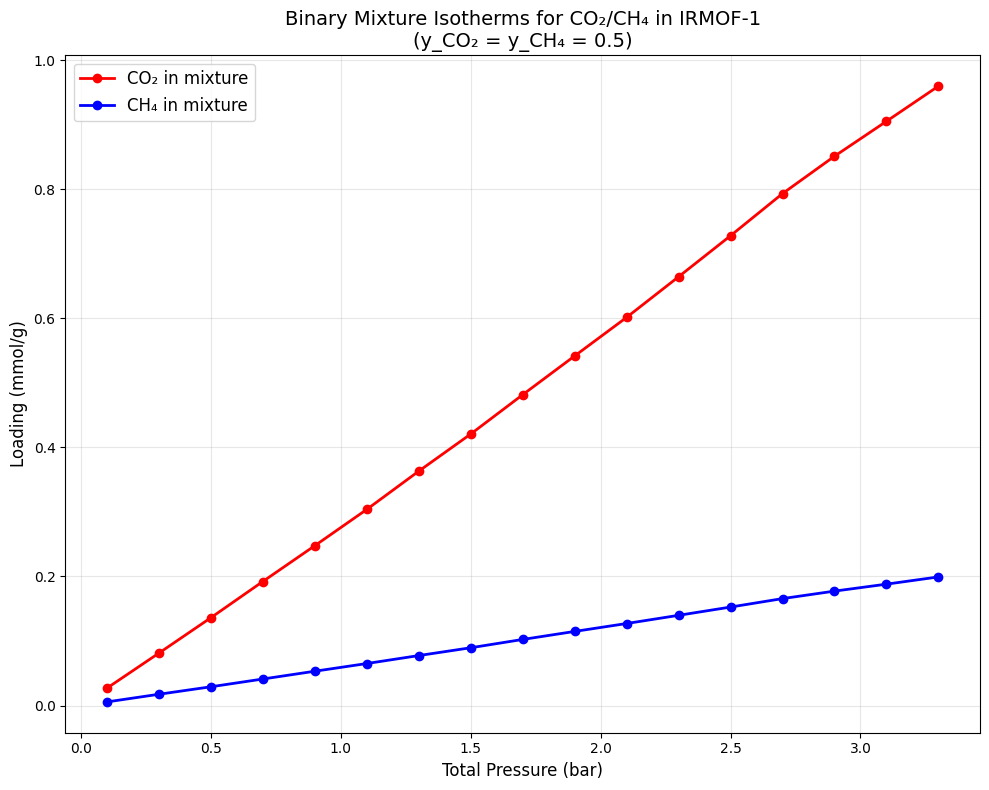

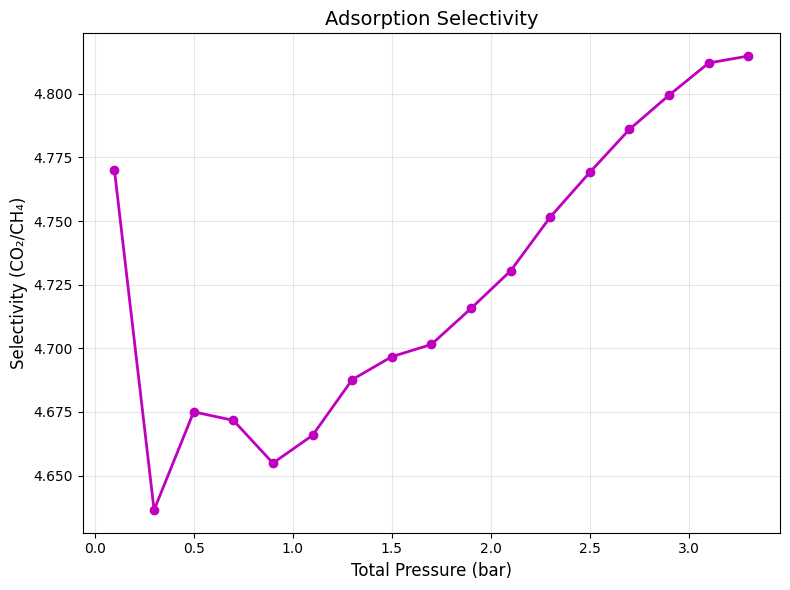


BINARY MIXTURE ISOTHERM RESULTS SUMMARY
Gas phase composition: y_CO₂ = 0.5, y_CH₄ = 0.5
Pressure range: 0.1 - 4.1000000000000005 bar
Number of pressure points: 21

First 10 data points:
   Pressure (bar)  CO₂ Loading (mmol/g)  CH₄ Loading (mmol/g)  \
0             0.1                0.0269                0.0056   
1             0.3                0.0812                0.0175   
2             0.5                0.1360                0.0291   
3             0.7                0.1922                0.0411   
4             0.9                0.2476                0.0532   
5             1.1                0.3038                0.0651   
6             1.3                0.3631                0.0775   
7             1.5                0.4206                0.0896   
8             1.7                0.4815                0.1024   
9             1.9                0.5416                0.1148   

   Total Loading (mmol/g)  Selectivity (CO₂/CH₄)  x_CO₂ (ads)  x_CH₄ (ads)  
0                  0

In [3]:
import pyiast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data (assuming the CSV files are available)
df_ch4 = pd.read_csv("CH4_IRMOF1.csv")
df_co2 = pd.read_csv("CO2_IRMOF1.csv")

# Clean the data - remove unnamed columns and NaN values
df_ch4_clean = df_ch4[['Pressure(bar)', 'Loading(mmol/g)']].dropna()
df_co2_clean = df_co2[['Pressure(bar)', 'Loading(mmol/g)']].dropna()

print("CH4 data shape:", df_ch4_clean.shape)
print("CO2 data shape:", df_co2_clean.shape)

# Create interpolator isotherms for pure components
ch4_isotherm = pyiast.InterpolatorIsotherm(df_ch4_clean,
                                    loading_key="Loading(mmol/g)",
                                    pressure_key="Pressure(bar)")

co2_isotherm = pyiast.InterpolatorIsotherm(df_co2_clean,
                                    loading_key="Loading(mmol/g)",
                                    pressure_key="Pressure(bar)")

# Define pressure range from 0.1 to 4.0 bar with increments of 0.2
pressures = np.arange(0.1, 4.2, 0.2)  # 4.2 to include 4.0
print(f"Pressure range: {len(pressures)} points from {pressures[0]} to {pressures[-1]} bar")

# Define gas mole fractions (50% each as specified)
y_co2 = 0.5  # CO2 mole fraction in gas phase
y_ch4 = 0.5  # CH4 mole fraction in gas phase

# Initialize arrays to store results
q_co2_mixture = []  # CO2 loading in mixture
q_ch4_mixture = []  # CH4 loading in mixture
q_total_mixture = []  # Total loading in mixture

print("\nCalculating binary mixture isotherms using IAST...")

# Calculate mixture isotherms using IAST
for P in pressures:
    try:
        # Calculate partial pressures
        p_co2 = y_co2 * P
        p_ch4 = y_ch4 * P
        
        partial_pressures = [p_co2, p_ch4]
        
        # Perform IAST calculation
        q_mixture = pyiast.iast(partial_pressures, 
                               [co2_isotherm, ch4_isotherm],
                               verboseflag=False)
        
        # Store results
        q_co2_mixture.append(q_mixture[0])  # CO2 loading
        q_ch4_mixture.append(q_mixture[1])  # CH4 loading
        q_total_mixture.append(q_mixture[0] + q_mixture[1])  # Total loading
        
    except Exception as e:
        print(f"Error at pressure {P} bar: {e}")
        q_co2_mixture.append(np.nan)
        q_ch4_mixture.append(np.nan)
        q_total_mixture.append(np.nan)

# Convert to numpy arrays
q_co2_mixture = np.array(q_co2_mixture)
q_ch4_mixture = np.array(q_ch4_mixture)
q_total_mixture = np.array(q_total_mixture)

# Create the main plot - Binary Mixture Isotherms
plt.figure(figsize=(10, 8))

# Plot CO2 and CH4 mixture isotherms on single graph
plt.plot(pressures, q_co2_mixture, 'ro-', label='CO₂ in mixture', markersize=6, linewidth=2)
plt.plot(pressures, q_ch4_mixture, 'bo-', label='CH₄ in mixture', markersize=6, linewidth=2)

plt.xlabel('Total Pressure (bar)', fontsize=12)
plt.ylabel('Loading (mmol/g)', fontsize=12)
plt.title('Binary Mixture Isotherms for CO₂/CH₄ in IRMOF-1\n(y_CO₂ = y_CH₄ = 0.5)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Additional analysis plot - Selectivity
plt.figure(figsize=(8, 6))
selectivity = q_co2_mixture / q_ch4_mixture
plt.plot(pressures, selectivity, 'mo-', markersize=6, linewidth=2)
plt.xlabel('Total Pressure (bar)', fontsize=12)
plt.ylabel('Selectivity (CO₂/CH₄)', fontsize=12)
plt.title('Adsorption Selectivity', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate mole fractions in adsorbed phase for results table
x_co2_ads = q_co2_mixture / (q_co2_mixture + q_ch4_mixture)
x_ch4_ads = q_ch4_mixture / (q_co2_mixture + q_ch4_mixture)

# Print summary results
print("\n" + "="*60)
print("BINARY MIXTURE ISOTHERM RESULTS SUMMARY")
print("="*60)
print(f"Gas phase composition: y_CO₂ = {y_co2}, y_CH₄ = {y_ch4}")
print(f"Pressure range: {pressures[0]} - {pressures[-1]} bar")
print(f"Number of pressure points: {len(pressures)}")

# Create summary table
results_df = pd.DataFrame({
    'Pressure (bar)': pressures,
    'CO₂ Loading (mmol/g)': q_co2_mixture,
    'CH₄ Loading (mmol/g)': q_ch4_mixture,
    'Total Loading (mmol/g)': q_total_mixture,
    'Selectivity (CO₂/CH₄)': selectivity,
    'x_CO₂ (ads)': x_co2_ads,
    'x_CH₄ (ads)': x_ch4_ads
})

print("\nFirst 10 data points:")
print(results_df.head(10).round(4))

print(f"\nAt 1 bar:")
idx_1bar = np.argmin(np.abs(pressures - 1.0))
print(f"  CO₂ loading: {q_co2_mixture[idx_1bar]:.4f} mmol/g")
print(f"  CH₄ loading: {q_ch4_mixture[idx_1bar]:.4f} mmol/g")
print(f"  Total loading: {q_total_mixture[idx_1bar]:.4f} mmol/g")
print(f"  Selectivity: {selectivity[idx_1bar]:.2f}")

print(f"\nAt 4 bar:")
idx_4bar = -1  # Last point
print(f"  CO₂ loading: {q_co2_mixture[idx_4bar]:.4f} mmol/g")
print(f"  CH₄ loading: {q_ch4_mixture[idx_4bar]:.4f} mmol/g")
print(f"  Total loading: {q_total_mixture[idx_4bar]:.4f} mmol/g")
print(f"  Selectivity: {selectivity[idx_4bar]:.2f}")

print(f"\nAverage selectivity over pressure range: {np.nanmean(selectivity):.2f}")
print(f"Maximum selectivity: {np.nanmax(selectivity):.2f} at {pressures[np.nanargmax(selectivity)]:.1f} bar")